# WiLI-2018 Language Identification — Benchmark & Model Export

**Course Project | Natural Language Processing**

---

## Abstract

This notebook benchmarks a range of language identification models on the **WiLI-2018** dataset, which covers 235 languages. We evaluate both classical machine learning approaches (TF-IDF + various classifiers) and neural models (fastText, GlotLID, CLD3, and a high-capacity Character-level CNN). All models are trained, evaluated, and exported for downstream use in an inference backend.

**Models covered:**
- Classical ML: Complement NB, SGD, Passive Aggressive, Ridge, Linear SVC
- LangDetect-style Naïve Bayes (char 1–3 gram TF-IDF)
- Neural: fastText, GlotLID, CLD3 (PyTorch implementations)
- Deep: High-capacity Character-level CNN

---

## 1. Environment Setup

In [1]:
# Install required packages
!pip install -q joblib torch scikit-learn matplotlib seaborn pandas numpy tqdm

## 2. Imports

In [2]:
import os, time, pickle, gc, warnings
import numpy as np
import pandas as pd
import joblib

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    f1_score, accuracy_score,
    confusion_matrix, classification_report
)
from sklearn.naive_bayes import ComplementNB
from sklearn.linear_model import (
    SGDClassifier, RidgeClassifier, PassiveAggressiveClassifier
)
from sklearn.svm import LinearSVC

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler
from tqdm.notebook import tqdm

## 3. Hardware Configuration

In [5]:
# Detect available GPUs
DEVICE   = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_GPUS = torch.cuda.device_count()
print(f"Device : {DEVICE}")
print(f"GPUs   : {NUM_GPUS}")

if NUM_GPUS > 1:
    for i in range(NUM_GPUS):
        name = torch.cuda.get_device_name(i)
        mem  = torch.cuda.get_device_properties(i).total_memory / 1e9
        print(f"  GPU {i}: {name}  ({mem:.1f} GB)")

Device : cuda
GPUs   : 2
  GPU 0: Tesla T4  (15.6 GB)
  GPU 1: Tesla T4  (15.6 GB)


In [6]:
# Directory for all saved model weights
SAVE_DIR = "./backend/weights/"
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Weights will be saved to: {SAVE_DIR}")

Weights will be saved to: ./backend/weights/


## 4. Data Loading & Preprocessing

In [ ]:
DATA_DIR = "./dataset/raw/"

## Reading Text file line by line
def read_lines(path):
    with open(path, encoding="utf-8") as f:
        return [l.strip() for l in f]

X_train_raw = read_lines(DATA_DIR + "x_train.txt")
y_train_raw = read_lines(DATA_DIR + "y_train.txt")
X_test_raw  = read_lines(DATA_DIR + "x_test.txt")
y_test_raw  = read_lines(DATA_DIR + "y_test.txt")

In [ ]:
# Generating pairs 
def drop_empty(texts, labels):
    """Remove samples with empty text."""
    pairs = [(t, l) for t, l in zip(texts, labels) if t.strip()]
    return zip(*pairs)

X_train_raw, y_train_raw = map(list, drop_empty(X_train_raw, y_train_raw))
X_test_raw,  y_test_raw  = map(list, drop_empty(X_test_raw,  y_test_raw))

print(f"Train samples : {len(X_train_raw):,}")
print(f"Test  samples : {len(X_test_raw):,}")

Train samples : 117,500
Test  samples : 117,500


In [ ]:
#Fit on combined labels to cover all classes
le = LabelEncoder()
le.fit(y_train_raw + y_test_raw)

y_train_enc = le.transform(y_train_raw)
y_test_enc  = le.transform(y_test_raw)

NUM_CLASSES = len(le.classes_)
print(f"Total languages : {NUM_CLASSES}")

#Save for inference
with open(SAVE_DIR + "label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)
print("LabelEncoder saved.")

Total languages : 235
LabelEncoder saved.


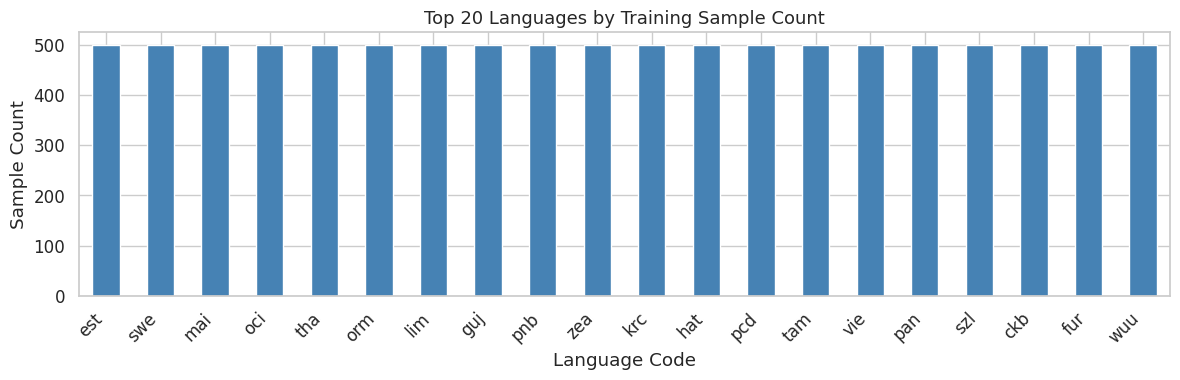

In [ ]:
#Quick look at class distribution (top 20 languages)
lang_counts = pd.Series(y_train_raw).value_counts().head(20)

fig, ax = plt.subplots(figsize=(12, 4))
lang_counts.plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Top 20 Languages by Training Sample Count", fontsize=13)
ax.set_xlabel("Language Code")
ax.set_ylabel("Sample Count")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 5. Classical Machine Learning Models

We use a character-level TF-IDF vectorizer (2–4 gram, 50k features) with six classifiers.

In [11]:
# Build TF-IDF feature matrix
vec_clf = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(2, 4),
    max_features=50_000,
    sublinear_tf=True
)

X_train_tfidf = vec_clf.fit_transform(X_train_raw)
X_test_tfidf  = vec_clf.transform(X_test_raw)
print(f"Feature matrix shape: {X_train_tfidf.shape}")

joblib.dump(vec_clf, SAVE_DIR + "vectorizer_char_wb_2_4.pkl")
print("Vectorizer saved.")

Feature matrix shape: (117500, 50000)
Vectorizer saved.


In [ ]:
# Define all classical classifiers
models_clf = {
    "ComplementNB"      : ComplementNB(),
    "SGDClassifier"     : SGDClassifier(
                              loss="modified_huber", class_weight="balanced",
                              random_state=42, n_jobs=-1),
    "PassiveAggressive" : PassiveAggressiveClassifier(
                              class_weight="balanced", random_state=42, n_jobs=-1),
    "RidgeClassifier"   : RidgeClassifier(class_weight="balanced"),
    "LinearSVC"         : LinearSVC(
                              class_weight="balanced", random_state=42, max_iter=2000)
}

In [13]:
# Train and evaluate each classical model
results_clf = []

for name, model in models_clf.items():
    print(f"\n--- {name} ---")

    t0 = time.time()
    model.fit(X_train_tfidf, y_train_enc)
    train_time = time.time() - t0

    t1 = time.time()
    y_pred = model.predict(X_test_tfidf)
    inf_time = time.time() - t1

    acc      = accuracy_score(y_test_enc, y_pred)
    macro_f1 = f1_score(y_test_enc, y_pred, average="macro", zero_division=0)
    print(f"  Accuracy: {acc:.4f}  |  Macro F1: {macro_f1:.4f}  "
          f"|  Train: {train_time:.1f}s  |  Infer: {inf_time:.2f}s")

    results_clf.append({
        "Model": name, "Accuracy": acc, "Macro F1": macro_f1,
        "Train Time (s)": train_time, "Infer Time (s)": inf_time,
        "Type": "Classical ML"
    })
    joblib.dump(model, SAVE_DIR + f"clf_{name}.pkl")

print("\nAll classical models saved.")


--- ComplementNB ---
  Accuracy: 0.9186  |  Macro F1: 0.9208  |  Train: 10.2s  |  Infer: 8.45s

--- SGDClassifier ---
  Accuracy: 0.9549  |  Macro F1: 0.9567  |  Train: 78.9s  |  Infer: 8.49s

--- PassiveAggressive ---
  Accuracy: 0.9631  |  Macro F1: 0.9634  |  Train: 108.1s  |  Infer: 8.56s

--- RidgeClassifier ---
  Accuracy: 0.9576  |  Macro F1: 0.9592  |  Train: 3367.8s  |  Infer: 9.39s

--- LinearSVC ---
  Accuracy: 0.9637  |  Macro F1: 0.9643  |  Train: 1055.1s  |  Infer: 9.37s

All classical models saved.


In [ ]:
# Summary table: classical ML
df_clf = pd.DataFrame(results_clf).sort_values("Macro F1", ascending=False)
df_clf.style.background_gradient(subset=["Accuracy", "Macro F1"], cmap="YlGn").format(
    {"Accuracy": "{:.4f}", "Macro F1": "{:.4f}",
     "Train Time (s)": "{:.1f}", "Infer Time (s)": "{:.2f}"}
)

,Model,Accuracy,Macro F1,Train Time (s),Infer Time (s),Type
4,LinearSVC,0.9637,0.9643,1055.1,9.37,Classical ML
2,PassiveAggressive,0.9631,0.9634,108.1,8.56,Classical ML
3,RidgeClassifier,0.9576,0.9592,3367.8,9.39,Classical ML
1,SGDClassifier,0.9549,0.9567,78.9,8.49,Classical ML
0,ComplementNB,0.9186,0.9208,10.2,8.45,Classical ML


## 6. LangDetect-Style Naïve Bayes

This mimics the classic **langdetect** library: Complement NB on character 1–3 grams.

In [15]:
# Smaller n-gram window, lower min_df
vec_ld = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(1, 3),
    max_features=50_000,
    sublinear_tf=True,
    min_df=2,
    strip_accents=None
)

X_train_ld = vec_ld.fit_transform(X_train_raw)
X_test_ld  = vec_ld.transform(X_test_raw)
print(f"Feature matrix shape: {X_train_ld.shape}")

Feature matrix shape: (117500, 50000)


In [16]:
model_ld = ComplementNB(alpha=0.1)

t0 = time.time()
model_ld.fit(X_train_ld, y_train_enc)
train_time_ld = time.time() - t0

t1 = time.time()
y_pred_ld = model_ld.predict(X_test_ld)
inf_time_ld = time.time() - t1

acc_ld      = accuracy_score(y_test_enc, y_pred_ld)
macro_f1_ld = f1_score(y_test_enc, y_pred_ld, average="macro", zero_division=0)
print(f"Accuracy: {acc_ld:.4f}  |  Macro F1: {macro_f1_ld:.4f}  "
      f"|  Train: {train_time_ld:.1f}s  |  Infer: {inf_time_ld:.2f}s")

Accuracy: 0.9105  |  Macro F1: 0.9126  |  Train: 8.5s  |  Infer: 7.07s


In [17]:
joblib.dump(vec_ld,   SAVE_DIR + "vectorizer_char_wb_1_3_langdetect.pkl")
joblib.dump(model_ld, SAVE_DIR + "langdetect_style_complement_nb.pkl")
print("LangDetect-style model saved.")

LangDetect-style model saved.


## 7. Deep Learning — Shared Utilities

All three neural models (fastText, GlotLID, CLD3) share a common n-gram hashing scheme and a training loop that supports **multi-GPU** via `nn.DataParallel`.

In [ ]:
##Extract character n-grams with boundary padding
def char_ngrams(text, min_n=2, max_n=4):
    text = f" {text} "
    ngrams = []
    for n in range(min_n, max_n + 1):
        ngrams += [text[i:i+n] for i in range(len(text) - n + 1)]
    return ngrams

##FNV-1a hash, mapped into [1, bucket_size-1].
def hash_ngram(ngram, bucket_size):
    h = 2166136261
    for ch in ngram.encode("utf-8", errors="replace"):
        h ^= ch
        h = (h * 16777619) & 0xFFFFFFFF
    return (h % (bucket_size - 1)) + 1

In [19]:
class LangDataset(Dataset):
    """Generic dataset for fastText / GlotLID."""
    def __init__(self, texts, labels, bucket_size, min_n, max_n):
        self.texts       = texts
        self.labels      = labels
        self.bucket_size = bucket_size
        self.min_n       = min_n
        self.max_n       = max_n

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        ngrams = char_ngrams(self.texts[idx], self.min_n, self.max_n)
        ids = [hash_ngram(g, self.bucket_size) for g in ngrams] if ngrams else [1]
        return torch.tensor(ids, dtype=torch.long), self.labels[idx]

def collate_fn(batch):
    seqs, labels = zip(*batch)
    padded = nn.utils.rnn.pad_sequence(seqs, batch_first=True, padding_value=0)
    return padded, torch.tensor([len(s) for s in seqs]), torch.tensor(labels, dtype=torch.long)

In [ ]:
# Generic training loop with:
#   -Multi-GPU via DataParallel
#   -Mixed precision (AMP)
#   -Gradient accumulation
#   -StepLR schedule

def train_eval(model, train_loader, test_loader, epochs=5, lr=1e-3,
               is_cld3=False, accum_steps=2):
    if NUM_GPUS > 1:
        model = nn.DataParallel(model)  # wrap for multi-GPU
    model.to(DEVICE)

    opt       = torch.optim.AdamW(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.StepLR(opt, step_size=2, gamma=0.5)
    criterion = nn.CrossEntropyLoss()
    scaler    = GradScaler('cuda')

    train_start = time.time()
    for epoch in range(epochs):
        model.train()
        opt.zero_grad()
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=True)

        for i, batch in enumerate(pbar):
            if is_cld3:
                uni, bi, tri, labels = [x.to(DEVICE, non_blocking=True) for x in batch]
                with autocast('cuda'):
                    out  = model(uni, bi, tri)
                    loss = criterion(out, labels) / accum_steps
            else:
                seqs, lengths, labels = [x.to(DEVICE, non_blocking=True) for x in batch]
                with autocast('cuda'):
                    out      = model(seqs, targets=labels)
                    raw_loss = out if hasattr(
                        model.module if NUM_GPUS > 1 else model, 'is_fasttext'
                    ) else criterion(out, labels)
                    loss     = raw_loss / accum_steps

            if NUM_GPUS > 1 and loss.dim() > 0:
                loss = loss.mean()  # reduce across GPUs

            scaler.scale(loss).backward()
            if (i + 1) % accum_steps == 0 or (i + 1) == len(train_loader):
                scaler.step(opt)
                scaler.update()
                opt.zero_grad()
            pbar.set_postfix(loss=f"{(loss.item() * accum_steps):.4f}")

        scheduler.step()
        torch.cuda.empty_cache()

    train_time = time.time() - train_start

    model.eval()
    all_preds, all_labels = [], []
    inf_start = time.time()

    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Evaluating", leave=True):
            if is_cld3:
                uni, bi, tri, labels = [x.to(DEVICE, non_blocking=True) for x in batch]
                with autocast('cuda'):
                    preds = model(uni, bi, tri).argmax(dim=1)
            else:
                seqs, lengths, labels = [x.to(DEVICE, non_blocking=True) for x in batch]
                with autocast('cuda'):
                    preds = model(seqs).argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    inf_time = time.time() - inf_start
    return np.array(all_preds), np.array(all_labels), train_time, inf_time

BATCH_SIZE  = 256
NUM_WORKERS = 2
print("Shared utilities ready.")

Shared utilities ready.


## 8. fastText Model

In [ ]:
class FastTextModel(nn.Module):
    def __init__(self, bucket_size, embed_dim, num_classes):
        super().__init__()
        self.is_fasttext = True
        self.embedding   = nn.EmbeddingBag(
            bucket_size, embed_dim, mode="mean", padding_idx=0, sparse=False
        )
        self.classifier  = nn.AdaptiveLogSoftmaxWithLoss(
            embed_dim, num_classes,
            cutoffs=[num_classes // 4, num_classes // 2], div_value=2.0
        )

    def forward(self, x, targets=None):
        emb = self.embedding(x)
        if targets is not None:
            return self.classifier(emb, targets).loss
        return self.classifier.log_prob(emb)

In [22]:
BUCKET_FT = 2_000_000
EMBED_FT  = 64

ft_train_ds = LangDataset(X_train_raw, y_train_enc, BUCKET_FT, min_n=2, max_n=4)
ft_test_ds  = LangDataset(X_test_raw,  y_test_enc,  BUCKET_FT, min_n=2, max_n=4)

ft_train_loader = DataLoader(
    ft_train_ds, batch_size=BATCH_SIZE, shuffle=True,
    collate_fn=collate_fn, num_workers=NUM_WORKERS, pin_memory=True
)
ft_test_loader  = DataLoader(
    ft_test_ds,  batch_size=BATCH_SIZE, shuffle=False,
    collate_fn=collate_fn, num_workers=NUM_WORKERS, pin_memory=True
)
print(f"fastText dataset — train: {len(ft_train_ds):,}  test: {len(ft_test_ds):,}")

fastText dataset — train: 117,500  test: 117,500


In [23]:
ft_model = FastTextModel(BUCKET_FT, EMBED_FT, NUM_CLASSES)

ft_preds, ft_labels, ft_tt, ft_it = train_eval(
    ft_model, ft_train_loader, ft_test_loader, epochs=5, lr=0.1
)

acc_ft = accuracy_score(ft_labels, ft_preds)
f1_ft  = f1_score(ft_labels, ft_preds, average="macro", zero_division=0)
print(f"fastText  —  Accuracy: {acc_ft:.4f}  |  Macro F1: {f1_ft:.4f}  "
      f"|  Train: {ft_tt:.1f}s  |  Infer: {ft_it:.2f}s")

torch.save(ft_model.state_dict(), SAVE_DIR + "fasttext_weights.pth")

Epoch 1/5:   0%|          | 0/459 [00:00<?, ?it/s]

Epoch 2/5:   0%|          | 0/459 [00:00<?, ?it/s]

Epoch 3/5:   0%|          | 0/459 [00:00<?, ?it/s]

Epoch 4/5:   0%|          | 0/459 [00:00<?, ?it/s]

Epoch 5/5:   0%|          | 0/459 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/459 [00:00<?, ?it/s]

fastText  —  Accuracy: 0.9522  |  Macro F1: 0.9526  |  Train: 579.9s  |  Infer: 105.90s


## 9. GlotLID Model

In [ ]:
class GlotLIDModel(nn.Module):
    def __init__(self, bucket_size, embed_dim, num_classes):
        super().__init__()
        self.embedding  = nn.EmbeddingBag(
            bucket_size, embed_dim, mode="mean", padding_idx=0, sparse=False
        )
        self.classifier = nn.Linear(embed_dim, num_classes)

    def forward(self, x, targets=None):
        return self.classifier(self.embedding(x))

In [25]:
GLOT_BUCKET = 2_000_000
GLOT_EMBED  = 128

gl_train_ds = LangDataset(X_train_raw, y_train_enc, GLOT_BUCKET, min_n=2, max_n=5)
gl_test_ds  = LangDataset(X_test_raw,  y_test_enc,  GLOT_BUCKET, min_n=2, max_n=5)

gl_train_loader = DataLoader(
    gl_train_ds, batch_size=BATCH_SIZE, shuffle=True,
    collate_fn=collate_fn, num_workers=NUM_WORKERS, pin_memory=True
)
gl_test_loader  = DataLoader(
    gl_test_ds,  batch_size=BATCH_SIZE, shuffle=False,
    collate_fn=collate_fn, num_workers=NUM_WORKERS, pin_memory=True
)

In [26]:
gl_model = GlotLIDModel(GLOT_BUCKET, GLOT_EMBED, NUM_CLASSES)

gl_preds, gl_labels, gl_tt, gl_it = train_eval(
    gl_model, gl_train_loader, gl_test_loader, epochs=5, lr=0.1
)

acc_gl = accuracy_score(gl_labels, gl_preds)
f1_gl  = f1_score(gl_labels, gl_preds, average="macro", zero_division=0)
print(f"GlotLID  —  Accuracy: {acc_gl:.4f}  |  Macro F1: {f1_gl:.4f}  "
      f"|  Train: {gl_tt:.1f}s  |  Infer: {gl_it:.2f}s")

torch.save(gl_model.state_dict(), SAVE_DIR + "glotlid_weights.pth")

Epoch 1/5:   0%|          | 0/459 [00:00<?, ?it/s]

Epoch 2/5:   0%|          | 0/459 [00:00<?, ?it/s]

Epoch 3/5:   0%|          | 0/459 [00:00<?, ?it/s]

Epoch 4/5:   0%|          | 0/459 [00:00<?, ?it/s]

Epoch 5/5:   0%|          | 0/459 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/459 [00:00<?, ?it/s]

GlotLID  —  Accuracy: 0.9697  |  Macro F1: 0.9706  |  Train: 833.8s  |  Infer: 146.43s


## 10. CLD3 Model

In [ ]:
##Produces separate uni-, bi-, tri-gram sequences per sample.
class CLD3Dataset(Dataset):
    def __init__(self, texts, labels, bucket_size):
        self.texts       = texts
        self.labels      = labels
        self.bucket_size = bucket_size

    def __len__(self): return len(self.texts)

    def _get_ids(self, text, n):
        text   = f" {text} "
        ngrams = [text[i:i+n] for i in range(len(text) - n + 1)]
        return [hash_ngram(g, self.bucket_size) for g in ngrams] if ngrams else [1]

    def __getitem__(self, idx):
        t = self.texts[idx]
        return (
            torch.tensor(self._get_ids(t, 1), dtype=torch.long),
            torch.tensor(self._get_ids(t, 2), dtype=torch.long),
            torch.tensor(self._get_ids(t, 3), dtype=torch.long),
            self.labels[idx]
        )

def cld3_collate(batch):
    uni, bi, tri, labels = zip(*batch)
    pad = lambda seqs: nn.utils.rnn.pad_sequence(seqs, batch_first=True, padding_value=0)
    return pad(uni), pad(bi), pad(tri), torch.tensor(labels, dtype=torch.long)

In [ ]:
##Three separate EmbeddingBags (uni/bi/tri) concatenated into a hidden layer.
class CLD3Model(nn.Module):
    def __init__(self, bucket_size, embed_dim, hidden_dim, num_classes):
        super().__init__()
        self.emb1 = nn.EmbeddingBag(bucket_size, embed_dim, mode="mean", padding_idx=0)
        self.emb2 = nn.EmbeddingBag(bucket_size, embed_dim, mode="mean", padding_idx=0)
        self.emb3 = nn.EmbeddingBag(bucket_size, embed_dim, mode="mean", padding_idx=0)
        self.hidden     = nn.Linear(embed_dim * 3, hidden_dim)
        self.relu       = nn.ReLU()
        self.dropout    = nn.Dropout(0.1)
        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, uni, bi, tri):
        x = torch.cat([self.emb1(uni), self.emb2(bi), self.emb3(tri)], dim=1)
        return self.classifier(self.dropout(self.relu(self.hidden(x))))

In [29]:
CLD3_BUCKET = 1_000_000
CLD3_EMBED  = 64
CLD3_HIDDEN = 256

cld3_train_ds = CLD3Dataset(X_train_raw, y_train_enc, CLD3_BUCKET)
cld3_test_ds  = CLD3Dataset(X_test_raw,  y_test_enc,  CLD3_BUCKET)

cld3_train_loader = DataLoader(
    cld3_train_ds, batch_size=BATCH_SIZE, shuffle=True,
    collate_fn=cld3_collate, num_workers=NUM_WORKERS, pin_memory=True
)
cld3_test_loader  = DataLoader(
    cld3_test_ds,  batch_size=BATCH_SIZE, shuffle=False,
    collate_fn=cld3_collate, num_workers=NUM_WORKERS, pin_memory=True
)

In [30]:
cld3_model = CLD3Model(CLD3_BUCKET, CLD3_EMBED, CLD3_HIDDEN, NUM_CLASSES)

cld3_preds, cld3_labels, cld3_tt, cld3_it = train_eval(
    cld3_model, cld3_train_loader, cld3_test_loader,
    epochs=5, lr=0.05, is_cld3=True
)

acc_cld3 = accuracy_score(cld3_labels, cld3_preds)
f1_cld3  = f1_score(cld3_labels, cld3_preds, average="macro", zero_division=0)
print(f"CLD3  —  Accuracy: {acc_cld3:.4f}  |  Macro F1: {f1_cld3:.4f}  "
      f"|  Train: {cld3_tt:.1f}s  |  Infer: {cld3_it:.2f}s")

torch.save(cld3_model.state_dict(), SAVE_DIR + "cld3_weights.pth")

# Free GPU memory before CNN
del ft_model, gl_model, cld3_model
gc.collect()
torch.cuda.empty_cache()

Epoch 1/5:   0%|          | 0/459 [00:00<?, ?it/s]

Epoch 2/5:   0%|          | 0/459 [00:00<?, ?it/s]

Epoch 3/5:   0%|          | 0/459 [00:00<?, ?it/s]

Epoch 4/5:   0%|          | 0/459 [00:00<?, ?it/s]

Epoch 5/5:   0%|          | 0/459 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/459 [00:00<?, ?it/s]

CLD3  —  Accuracy: 0.9545  |  Macro F1: 0.9549  |  Train: 553.7s  |  Infer: 98.64s


## 11. Character-Level CNN (High Capacity)

A multi-kernel CNN operating directly on raw Unicode character IDs. This is the heaviest model but captures fine-grained orthographic patterns.

In [31]:
class CharDataset(Dataset):
    def __init__(self, texts, labels, vocab_size, max_seq_len):
        self.texts       = texts
        self.labels      = labels
        self.vocab_size  = vocab_size
        self.max_seq_len = max_seq_len

    def __len__(self): return len(self.texts)

    def __getitem__(self, idx):
        text = f" {self.texts[idx]} "[:self.max_seq_len]
        ids  = [(hash(ch) % (self.vocab_size - 1)) + 1 for ch in text]
        return torch.tensor(ids, dtype=torch.long), self.labels[idx]

def char_collate_fn(batch):
    seqs, labels = zip(*batch)
    padded = nn.utils.rnn.pad_sequence(seqs, batch_first=True, padding_value=0)
    if padded.size(1) < 7:  # min kernel size guard
        padded = F.pad(padded, (0, 7 - padded.size(1)), value=0)
    return padded, torch.tensor(labels, dtype=torch.long)

In [ ]:
##Parallel conv banks with max-over-time pooling.
class CharCNNModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes, filter_sizes, num_filters):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.convs = nn.ModuleList([
            nn.Conv1d(embed_dim, num_filters, kernel_size=k)
            for k in filter_sizes
        ])
        self.bns     = nn.ModuleList([nn.BatchNorm1d(num_filters) for _ in filter_sizes])
        self.dropout = nn.Dropout(0.5)
        self.fc      = nn.Linear(len(filter_sizes) * num_filters, num_classes)

    def forward(self, x):
        x = self.embedding(x).permute(0, 2, 1)  # (B, E, L)
        pooled = [torch.max(F.relu(bn(conv(x))), dim=2)[0]
                  for conv, bn in zip(self.convs, self.bns)]
        return self.fc(self.dropout(torch.cat(pooled, dim=1)))

In [ ]:
##CNN-specific training loop with cosine LR schedule and label smoothing.
def train_eval_cnn(model, train_loader, test_loader, epochs=20, lr=1e-3, accum_steps=4):
    if NUM_GPUS > 1:
        model = nn.DataParallel(model)
    model.to(DEVICE)

    opt       = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=1e-5)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
    scaler    = GradScaler('cuda')

    train_start = time.time()
    for epoch in range(epochs):
        model.train()
        opt.zero_grad()
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=True)

        for i, (seqs, labels) in enumerate(pbar):
            seqs, labels = seqs.to(DEVICE, non_blocking=True), labels.to(DEVICE, non_blocking=True)
            with autocast('cuda'):
                loss = criterion(model(seqs), labels) / accum_steps
            if NUM_GPUS > 1 and loss.dim() > 0:
                loss = loss.mean()
            scaler.scale(loss).backward()
            if (i + 1) % accum_steps == 0 or (i + 1) == len(train_loader):
                scaler.step(opt)
                scaler.update()
                opt.zero_grad()
            pbar.set_postfix(
                loss=f"{(loss.item() * accum_steps):.4f}",
                lr=f"{scheduler.get_last_lr()[0]:.5f}"
            )
        scheduler.step()
        torch.cuda.empty_cache()

    train_time = time.time() - train_start

    model.eval()
    all_preds, all_labels = [], []
    inf_start = time.time()
    with torch.no_grad():
        for seqs, labels in tqdm(test_loader, desc="Evaluating", leave=True):
            seqs = seqs.to(DEVICE, non_blocking=True)
            with autocast('cuda'):
                preds = model(seqs).argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    inf_time = time.time() - inf_start

    return np.array(all_preds), np.array(all_labels), train_time, inf_time

In [34]:
# CNN hyperparameters
CHAR_VOCAB      = 65_536
CHAR_EMBED      = 128
NUM_FILTERS     = 256
FILTER_SIZES    = [2, 3, 4, 5, 6, 7]
MAX_SEQ_LEN     = 768
BATCH_SIZE_CNN  = 128
ACCUM_STEPS_CNN = 4
EPOCHS_CNN      = 20

print(f"Batch: {BATCH_SIZE_CNN} | Accum: {ACCUM_STEPS_CNN} | Epochs: {EPOCHS_CNN}")

Batch: 128 | Accum: 4 | Epochs: 20


In [35]:
cnn_train_ds = CharDataset(X_train_raw, y_train_enc, CHAR_VOCAB, MAX_SEQ_LEN)
cnn_test_ds  = CharDataset(X_test_raw,  y_test_enc,  CHAR_VOCAB, MAX_SEQ_LEN)

cnn_train_loader = DataLoader(
    cnn_train_ds, batch_size=BATCH_SIZE_CNN, shuffle=True,
    collate_fn=char_collate_fn, num_workers=NUM_WORKERS, pin_memory=True
)
cnn_test_loader  = DataLoader(
    cnn_test_ds,  batch_size=BATCH_SIZE_CNN, shuffle=False,
    collate_fn=char_collate_fn, num_workers=NUM_WORKERS, pin_memory=True
)

In [36]:
cnn_model = CharCNNModel(
    vocab_size=CHAR_VOCAB, embed_dim=CHAR_EMBED,
    num_classes=NUM_CLASSES, filter_sizes=FILTER_SIZES, num_filters=NUM_FILTERS
)

cnn_preds, cnn_labels, cnn_tt, cnn_it = train_eval_cnn(
    cnn_model, cnn_train_loader, cnn_test_loader,
    epochs=EPOCHS_CNN, lr=1e-3, accum_steps=ACCUM_STEPS_CNN
)

acc_cnn = accuracy_score(cnn_labels, cnn_preds)
f1_cnn  = f1_score(cnn_labels, cnn_preds, average="macro", zero_division=0)
print(f"CharCNN  —  Accuracy: {acc_cnn:.4f}  |  Macro F1: {f1_cnn:.4f}  "
      f"|  Train: {cnn_tt:.1f}s  |  Infer: {cnn_it:.2f}s")

torch.save(cnn_model.state_dict(), SAVE_DIR + "charcnn_highcap_weights.pth")

Epoch 1/20:   0%|          | 0/918 [00:00<?, ?it/s]

Epoch 2/20:   0%|          | 0/918 [00:00<?, ?it/s]

Epoch 3/20:   0%|          | 0/918 [00:00<?, ?it/s]

Epoch 4/20:   0%|          | 0/918 [00:00<?, ?it/s]

Epoch 5/20:   0%|          | 0/918 [00:00<?, ?it/s]

...

Epoch 18/20:   0%|          | 0/918 [00:00<?, ?it/s]

Epoch 19/20:   0%|          | 0/918 [00:00<?, ?it/s]

Epoch 20/20:   0%|          | 0/918 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/918 [00:00<?, ?it/s]

CharCNN  —  Accuracy: 0.9599  |  Macro F1: 0.9615  |  Train: 1269.1s  |  Infer: 34.43s


In [37]:
del cnn_model, cnn_train_loader, cnn_test_loader
gc.collect()
torch.cuda.empty_cache()
print("GPU memory freed.")

GPU memory freed.


## 12. Results Analysis

We now consolidate all results and produce several diagnostic plots.

In [38]:
# Collect DL results alongside classical ones
results_dl = [
    {"Model": "LangDetect-NB",  "Accuracy": acc_ld,   "Macro F1": macro_f1_ld,
     "Train Time (s)": train_time_ld,  "Infer Time (s)": inf_time_ld,   "Type": "Classical ML"},
    {"Model": "fastText",       "Accuracy": acc_ft,   "Macro F1": f1_ft,
     "Train Time (s)": ft_tt,           "Infer Time (s)": ft_it,          "Type": "Neural"},
    {"Model": "GlotLID",        "Accuracy": acc_gl,   "Macro F1": f1_gl,
     "Train Time (s)": gl_tt,           "Infer Time (s)": gl_it,          "Type": "Neural"},
    {"Model": "CLD3",           "Accuracy": acc_cld3, "Macro F1": f1_cld3,
     "Train Time (s)": cld3_tt,         "Infer Time (s)": cld3_it,        "Type": "Neural"},
    {"Model": "CharCNN",        "Accuracy": acc_cnn,  "Macro F1": f1_cnn,
     "Train Time (s)": cnn_tt,          "Infer Time (s)": cnn_it,         "Type": "Deep CNN"},
]

df_all = pd.DataFrame(results_clf + results_dl).sort_values("Macro F1", ascending=False).reset_index(drop=True)
df_all

,Model,Accuracy,Macro F1,Train Time (s),Infer Time (s),Type
0,GlotLID,0.969711,0.970625,833.823988,146.430528,Neural
1,LinearSVC,0.963719,0.964314,1055.073059,9.365916,Classical ML
2,PassiveAggressive,0.963123,0.963385,108.145959,8.563318,Classical ML
3,CharCNN,0.959855,0.961492,1269.129583,34.431192,Deep CNN
4,RidgeClassifier,0.957609,0.959181,3367.757594,9.393425,Classical ML
5,SGDClassifier,0.954877,0.956651,78.873289,8.490739,Classical ML
6,CLD3,0.954536,0.954945,553.682245,98.644144,Neural
7,fastText,0.952179,0.952552,579.895278,105.895524,Neural
8,ComplementNB,0.918596,0.920778,10.153274,8.450016,Classical ML
9,LangDetect-NB,0.910494,0.912554,8.495400,7.074910,Classical ML


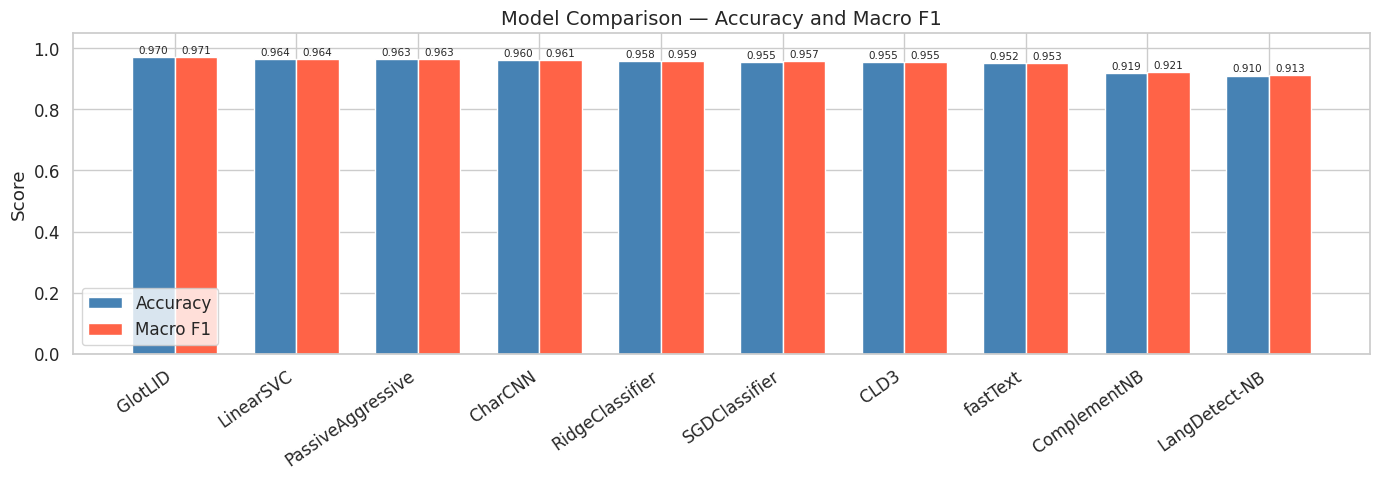

In [ ]:
##Plot 1: Accuracy vs Macro F1 grouped bar chart
fig, ax = plt.subplots(figsize=(14, 5))

x     = np.arange(len(df_all))
width = 0.35

bars1 = ax.bar(x - width/2, df_all["Accuracy"],  width, label="Accuracy",  color="steelblue")
bars2 = ax.bar(x + width/2, df_all["Macro F1"],  width, label="Macro F1",  color="tomato")

ax.set_xticks(x)
ax.set_xticklabels(df_all["Model"], rotation=35, ha="right")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Model Comparison — Accuracy and Macro F1", fontsize=14)
ax.legend()

# add value labels on top of each bar
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{bar.get_height():.3f}", ha='center', va='bottom', fontsize=7.5)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{bar.get_height():.3f}", ha='center', va='bottom', fontsize=7.5)

plt.tight_layout()
plt.show()

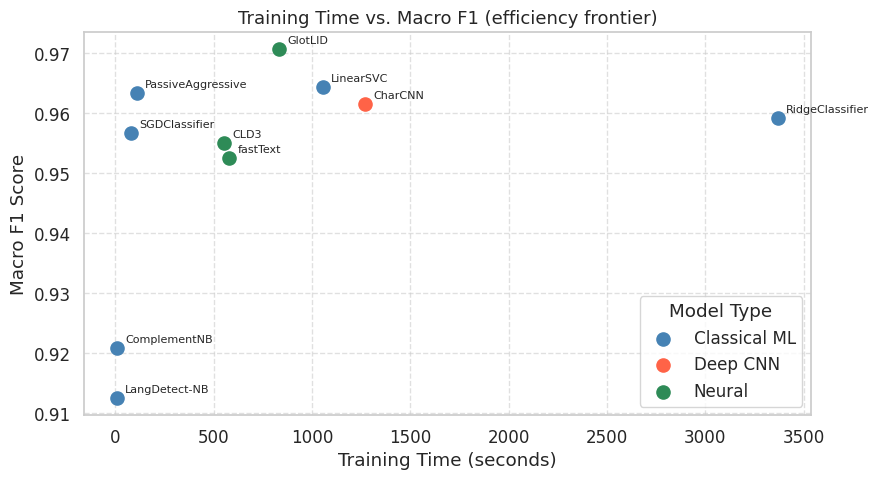

In [ ]:
##Plot 2: Training Time vs Macro F1 scatter
palette = {"Classical ML": "steelblue", "Neural": "seagreen", "Deep CNN": "tomato"}

fig, ax = plt.subplots(figsize=(9, 5))
for mtype, group in df_all.groupby("Type"):
    ax.scatter(
        group["Train Time (s)"], group["Macro F1"],
        label=mtype, s=90, color=palette[mtype], zorder=3
    )
    for _, row in group.iterrows():
        ax.annotate(row["Model"], (row["Train Time (s)"], row["Macro F1"]),
                    textcoords="offset points", xytext=(6, 4), fontsize=8)

ax.set_xlabel("Training Time (seconds)")
ax.set_ylabel("Macro F1 Score")
ax.set_title("Training Time vs. Macro F1 (efficiency frontier)", fontsize=13)
ax.legend(title="Model Type")
ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

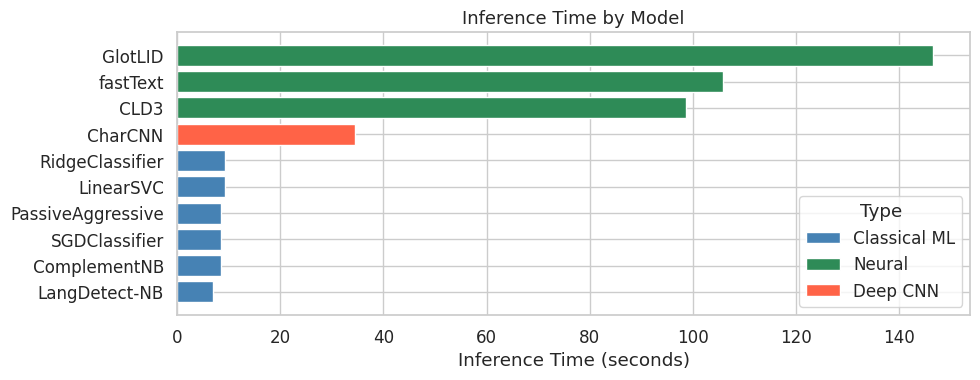

In [ ]:
##Plot 3: Inference Time Comparison (bar)
df_sorted_inf = df_all.sort_values("Infer Time (s)")

fig, ax = plt.subplots(figsize=(10, 4))
colors  = [palette[t] for t in df_sorted_inf["Type"]]
ax.barh(df_sorted_inf["Model"], df_sorted_inf["Infer Time (s)"], color=colors, edgecolor="white")
ax.set_xlabel("Inference Time (seconds)")
ax.set_title("Inference Time by Model", fontsize=13)

# legend patches
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k, v in palette.items()]
ax.legend(handles=legend_elements, title="Type")
plt.tight_layout()
plt.show()

Best model: GlotLID  (Macro F1 = 0.9706)


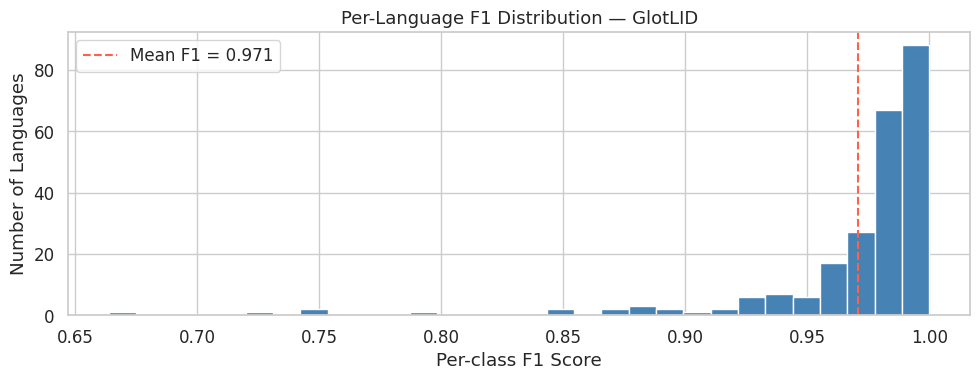

In [ ]:
##Plot 4: Per-class F1 distribution for the best model
# Use whichever model had the highest macro F1
best_row   = df_all.iloc[0]
best_name  = best_row["Model"]
print(f"Best model: {best_name}  (Macro F1 = {best_row['Macro F1']:.4f})")

##Map model name to its predictions
preds_map = {
    "fastText": ft_preds, "GlotLID": gl_preds,
    "CLD3": cld3_preds,   "CharCNN": cnn_preds,
    "LangDetect-NB": y_pred_ld,
}
##For classical models we need to re-predict (already saved)
##Just grab the best available from neural pool if needed
best_preds = preds_map.get(best_name)
best_true  = y_test_enc  # all share the same test set

if best_preds is None:
    print("Predictions for this model not in memory — skipping per-class plot.")
else:
    per_class_f1 = f1_score(best_true, best_preds, average=None, zero_division=0)
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(per_class_f1, bins=30, color="steelblue", edgecolor="white")
    ax.axvline(per_class_f1.mean(), color="tomato", linestyle="--",
               label=f"Mean F1 = {per_class_f1.mean():.3f}")
    ax.set_xlabel("Per-class F1 Score")
    ax.set_ylabel("Number of Languages")
    ax.set_title(f"Per-Language F1 Distribution — {best_name}", fontsize=13)
    ax.legend()
    plt.tight_layout()
    plt.show()

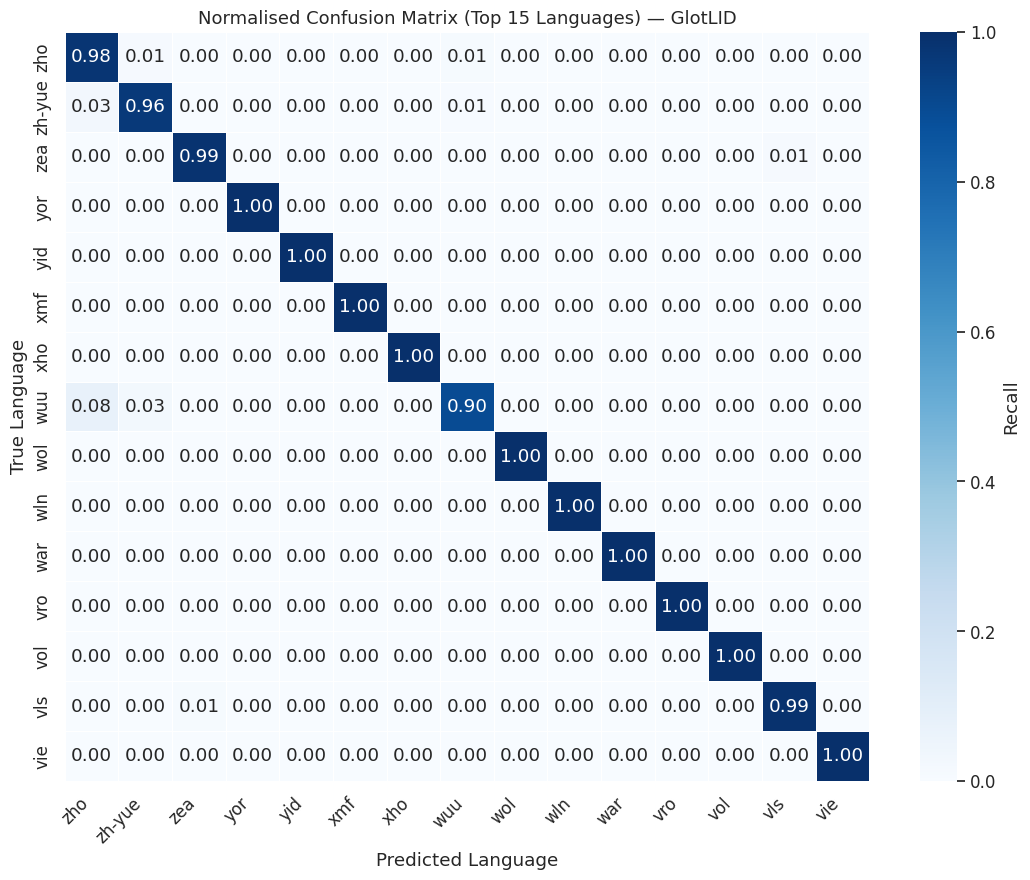

In [ ]:
## Plot 5: Confusion matrix: top 15 most frequent languages
if best_preds is not None:
    top_n     = 15
    top_idx   = np.argsort(np.bincount(best_true))[::-1][:top_n]
    top_langs = le.classes_[top_idx]

    mask      = np.isin(best_true, top_idx)
    true_sub  = best_true[mask]
    pred_sub  = best_preds[mask]

    idx_map   = {v: i for i, v in enumerate(top_idx)}
    true_r    = np.array([idx_map[v] for v in true_sub])
    pred_r    = np.array([idx_map.get(v, top_n) for v in pred_sub])  # out-of-top goes to bin top_n
    mask2     = pred_r < top_n
    cm        = confusion_matrix(true_r[mask2], pred_r[mask2])
    cm_norm   = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, ax = plt.subplots(figsize=(11, 9))
    sns.heatmap(
        cm_norm, annot=True, fmt=".2f", cmap="Blues",
        xticklabels=top_langs, yticklabels=top_langs,
        linewidths=0.4, ax=ax, cbar_kws={"label": "Recall"}
    )
    ax.set_xlabel("Predicted Language")
    ax.set_ylabel("True Language")
    ax.set_title(f"Normalised Confusion Matrix (Top {top_n} Languages) — {best_name}", fontsize=13)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

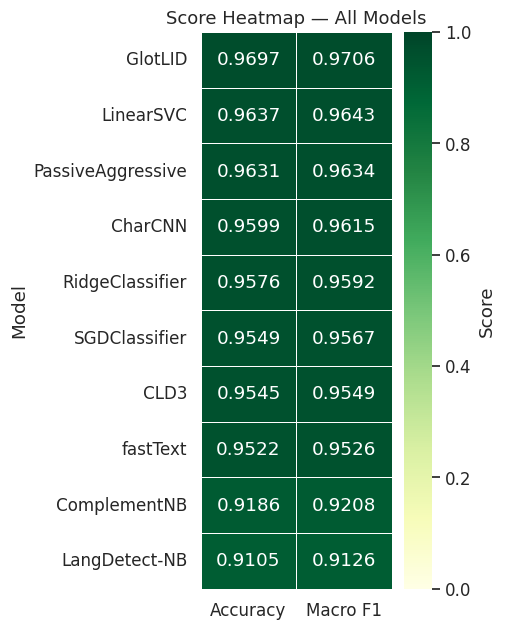

In [ ]:
## Plot 6: Macro F1 heatmap across all models (summary)
df_heat = df_all.set_index("Model")[["Accuracy", "Macro F1"]]

fig, ax = plt.subplots(figsize=(5, len(df_heat) * 0.55 + 1))
sns.heatmap(
    df_heat, annot=True, fmt=".4f", cmap="YlGn",
    linewidths=0.5, ax=ax, vmin=0.0, vmax=1.0,
    cbar_kws={"label": "Score"}
)
ax.set_title("Score Heatmap — All Models", fontsize=13)
plt.tight_layout()
plt.show()

## 13. Saved Model Inventory

In [45]:
print(f"\n{'='*60}")
print(f"  ALL MODELS TRAINED AND SAVED  →  {SAVE_DIR}")
print(f"{'='*60}")

for fname in sorted(os.listdir(SAVE_DIR)):
    size_mb = os.path.getsize(os.path.join(SAVE_DIR, fname)) / 1e6
    print(f"  {fname:<50} {size_mb:>7.1f} MB")

print(f"{'='*60}")


  ALL MODELS TRAINED AND SAVED  →  ./backend/weights/
  charcnn_highcap_weights.pth                           38.6 MB
  cld3_weights.pth                                     768.4 MB
  clf_ComplementNB.pkl                                 188.4 MB
  clf_LinearSVC.pkl                                     94.0 MB
  clf_PassiveAggressive.pkl                             94.0 MB
  clf_RidgeClassifier.pkl                               94.0 MB
  clf_SGDClassifier.pkl                                 94.0 MB
  fasttext_weights.pth                                 512.0 MB
  glotlid_weights.pth                                 1024.1 MB
  label_encoder.pkl                                      0.0 MB
  langdetect_style_complement_nb.pkl                   188.4 MB
  vectorizer_char_wb_1_3_langdetect.pkl                  1.7 MB
  vectorizer_char_wb_2_4.pkl                             1.7 MB
